# Task 2: Credit Risk Prediction

## Objective
The objective of this project is to predict whether a loan applicant is likely to default on a loan or become seriously delinquent within two years.

## Dataset
This project uses the Kaggle Give Me Some Credit dataset.  
The target column is `SeriousDlqin2yrs`.

- `0` means customer did not default.
- `1` means customer defaulted or became seriously delinquent.

## Skills Covered
- Data loading and understanding
- Missing value handling
- Exploratory Data Analysis
- Data visualization
- Binary classification
- Logistic Regression
- Decision Tree Classifier
- Confusion Matrix
- Accuracy, Precision, Recall, F1 Score, ROC-AUC
- Model saving for dashboard deployment

In [3]:
# Basic libraries
import os
import warnings
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error
)

# Model saving
import joblib

warnings.filterwarnings("ignore")

# Visualization style
sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

In [4]:
# Main project folder path
PROJECT_DIR = Path(r"D:\Credit Risk Prediction")

# Folder paths
DATA_DIR = PROJECT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
REPORT_DIR = PROJECT_DIR / "outputs" / "reports"

# Create folders if not already created
for folder in [RAW_DATA_DIR, NOTEBOOK_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready.")
print("Project path:", PROJECT_DIR)

Project folders are ready.
Project path: D:\Credit Risk Prediction


In [5]:
print("Files available in raw data folder:")

for file in RAW_DATA_DIR.iterdir():
    print(file.name)

Files available in raw data folder:
cs-test.csv
cs-training.csv
Data Dictionary.xls
sampleEntry.csv


In [6]:
train_path = RAW_DATA_DIR / "cs-training.csv"

df = pd.read_csv(train_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
data = df.copy()

# Remove unnecessary index column if present
if "Unnamed: 0" in data.columns:
    data.drop(columns=["Unnamed: 0"], inplace=True)

print("Columns after cleaning:")
data.columns.tolist()

Columns after cleaning:


['SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [8]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nDataset Information:")
data.info()

Dataset Shape: (150000, 11)

Column Names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [10]:
missing_values = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Percentage": (data.isnull().sum() / len(data)) * 100
})

missing_values = missing_values[missing_values["Missing Values"] > 0]
missing_values = missing_values.sort_values(by="Percentage", ascending=False)

missing_values

,Missing Values,Percentage
MonthlyIncome,29731,19.820667
NumberOfDependents,3924,2.616000


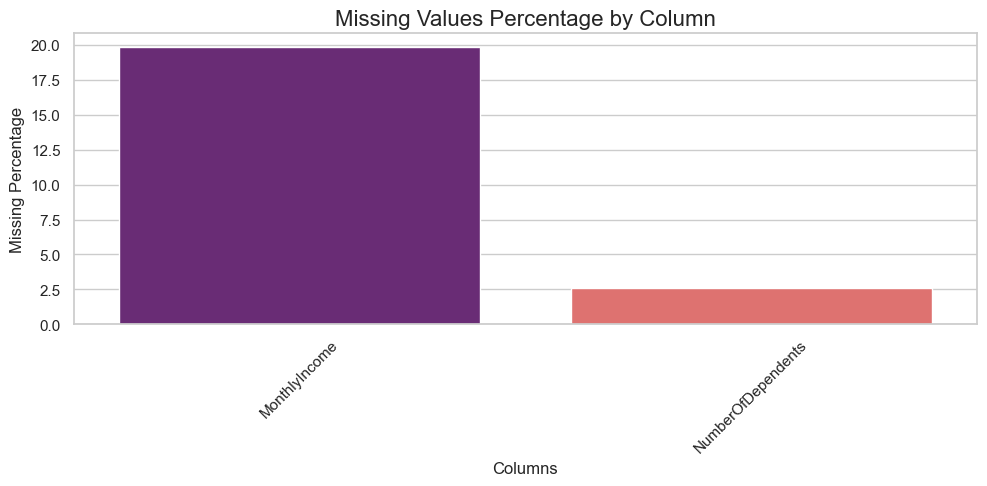

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_values.index,
    y=missing_values["Percentage"],
    palette="magma"
)

plt.title("Missing Values Percentage by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "missing_values_percentage.png", dpi=300)
plt.show()

In [12]:
duplicate_count = data.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 609


In [13]:
target_column = "SeriousDlqin2yrs"

target_summary = pd.DataFrame({
    "Count": data[target_column].value_counts(),
    "Percentage": data[target_column].value_counts(normalize=True) * 100
})

target_summary

,Count,Percentage
SeriousDlqin2yrs,,
0,139974,93.316
1,10026,6.684


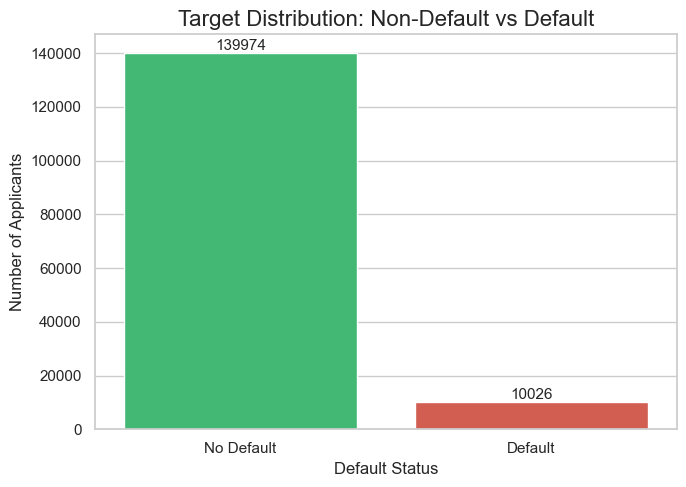

In [14]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=data,
    x=target_column,
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("Target Distribution: Non-Default vs Default")
plt.xlabel("Default Status")
plt.ylabel("Number of Applicants")
plt.xticks([0, 1], ["No Default", "Default"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", dpi=300)
plt.show()

## Target Distribution Explanation

The dataset is imbalanced. Most applicants did not default, while fewer applicants defaulted.

This is common in credit risk prediction because real-world default cases are usually smaller in number.

Because of this imbalance, accuracy alone is not enough.  
We will also check precision, recall, F1-score and ROC-AUC.

In [15]:
clean_data = data.copy()

# Fill MonthlyIncome missing values with median
clean_data["MonthlyIncome"] = clean_data["MonthlyIncome"].fillna(
    clean_data["MonthlyIncome"].median()
)

# Fill NumberOfDependents missing values with median
clean_data["NumberOfDependents"] = clean_data["NumberOfDependents"].fillna(
    clean_data["NumberOfDependents"].median()
)

print("Missing values after handling:")
clean_data.isnull().sum()

Missing values after handling:


SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [16]:
outlier_columns = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

for col in outlier_columns:
    lower_limit = clean_data[col].quantile(0.01)
    upper_limit = clean_data[col].quantile(0.99)
    clean_data[col] = clean_data[col].clip(lower=lower_limit, upper=upper_limit)

print("Outlier capping completed successfully.")

Outlier capping completed successfully.


In [17]:
clean_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.000000
RevolvingUtilizationOfUnsecuredLines,150000.0,0.320496,0.352152,0.0,0.029867,0.154181,0.559046,1.092956
age,150000.0,52.279260,14.668105,24.0,41.000000,52.000000,63.000000,87.000000
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.245860,0.666815,0.0,0.000000,0.000000,0.000000,4.000000
DebtRatio,150000.0,316.548869,906.962222,0.0,0.175074,0.366508,0.868254,4979.040000
MonthlyIncome,150000.0,6142.445313,3835.678657,0.0,3903.000000,5400.000000,7400.000000,23000.000000
NumberOfOpenCreditLinesAndLoans,150000.0,8.404000,4.946399,0.0,5.000000,8.000000,11.000000,24.000000
NumberOfTimes90DaysLate,150000.0,0.086487,0.401673,0.0,0.000000,0.000000,0.000000,3.000000
NumberRealEstateLoansOrLines,150000.0,0.992600,0.985802,0.0,0.000000,1.000000,2.000000,4.000000
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.063180,0.290107,0.0,0.000000,0.000000,0.000000,2.000000


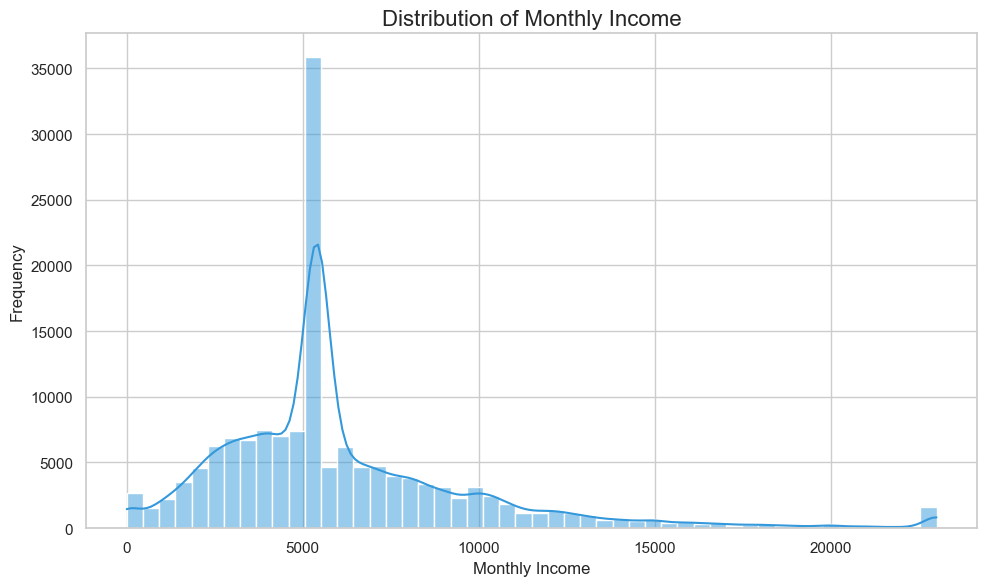

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    clean_data["MonthlyIncome"],
    bins=50,
    kde=True,
    color="#3498db"
)

plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "monthly_income_distribution.png", dpi=300)
plt.show()

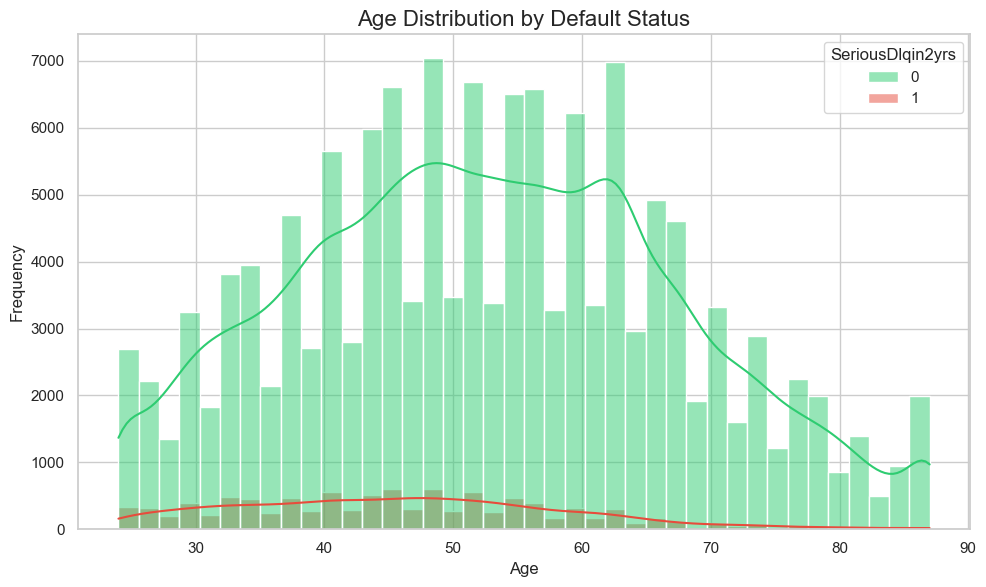

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=clean_data,
    x="age",
    hue=target_column,
    bins=40,
    kde=True,
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("Age Distribution by Default Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "age_distribution_by_default.png", dpi=300)
plt.show()

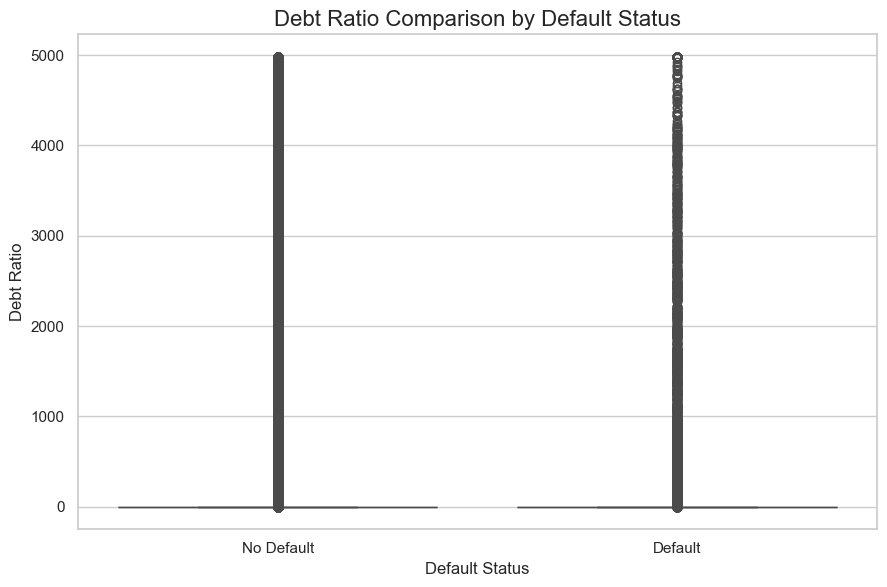

In [20]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_data,
    x=target_column,
    y="DebtRatio",
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("Debt Ratio Comparison by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Debt Ratio")
plt.xticks([0, 1], ["No Default", "Default"])
plt.tight_layout()

plt.savefig(FIGURE_DIR / "debt_ratio_boxplot.png", dpi=300)
plt.show()

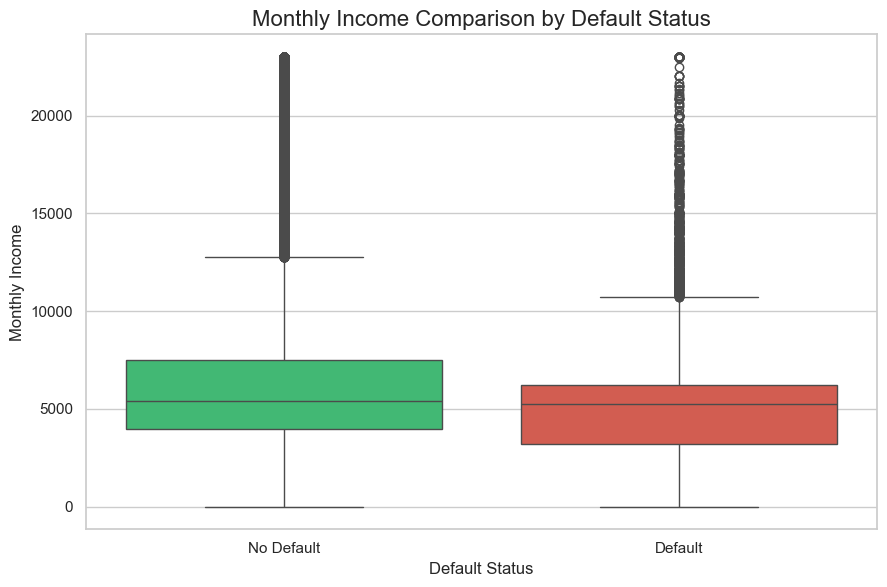

In [21]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_data,
    x=target_column,
    y="MonthlyIncome",
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("Monthly Income Comparison by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Monthly Income")
plt.xticks([0, 1], ["No Default", "Default"])
plt.tight_layout()

plt.savefig(FIGURE_DIR / "monthly_income_default_boxplot.png", dpi=300)
plt.show()

In [22]:
past_due_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

past_due_avg = clean_data.groupby(target_column)[past_due_columns].mean().T

past_due_avg

SeriousDlqin2yrs,0,1
NumberOfTime30-59DaysPastDueNotWorse,0.194479,0.963196
NumberOfTimes90DaysLate,0.049031,0.609416
NumberOfTime60-89DaysPastDueNotWorse,0.040822,0.375324


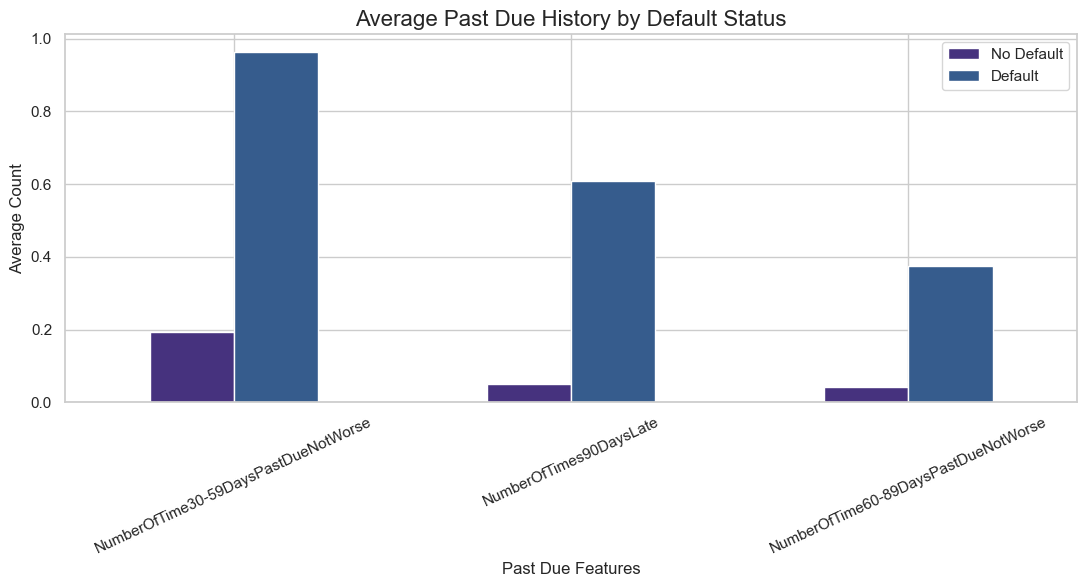

In [23]:
past_due_avg.plot(kind="bar", figsize=(11, 6))

plt.title("Average Past Due History by Default Status")
plt.xlabel("Past Due Features")
plt.ylabel("Average Count")
plt.xticks(rotation=25)
plt.legend(["No Default", "Default"])
plt.tight_layout()

plt.savefig(FIGURE_DIR / "past_due_average_comparison.png", dpi=300)
plt.show()

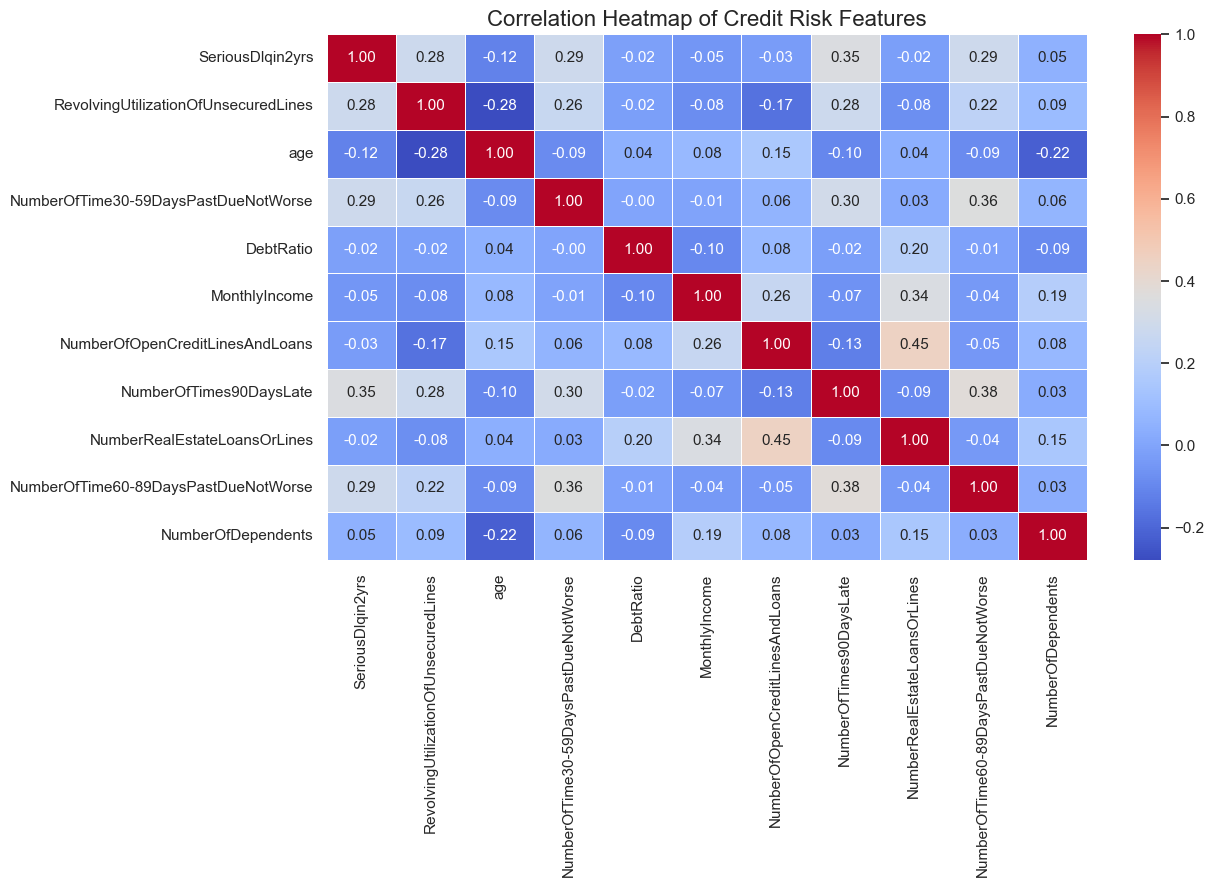

In [24]:
plt.figure(figsize=(13, 9))

correlation = clean_data.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Credit Risk Features")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

## EDA Key Insights

1. The dataset is imbalanced because non-default applicants are much higher than default applicants.
2. MonthlyIncome and NumberOfDependents had missing values.
3. Missing values were handled using median imputation.
4. Extreme values were capped using percentile-based outlier treatment.
5. Past due payment history is very important for predicting credit default.
6. Debt ratio and monthly income also help in understanding applicant financial risk.

# Model Training

In [25]:
X = clean_data.drop(columns=[target_column])
y = clean_data[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150000, 10)
Target shape: (150000,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120000, 10)
Testing data shape: (30000, 10)


In [27]:
# Logistic Regression Model
logistic_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [28]:
decision_tree_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [29]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    This function evaluates a classification model using:
    Accuracy, Precision, Recall, F1 Score, ROC-AUC, MAE, RMSE and Confusion Matrix.
    """

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Default", "Default"],
        yticklabels=["No Default", "Default"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    filename = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(FIGURE_DIR / filename, dpi=300)
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "MAE": mae,
        "RMSE": rmse
    }

Logistic Regression
Accuracy: 0.8054
Precision: 0.2196
Recall: 0.7486
F1 Score: 0.3396
ROC-AUC: 0.8614
MAE: 0.1946
RMSE: 0.4411

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.81      0.85     30000



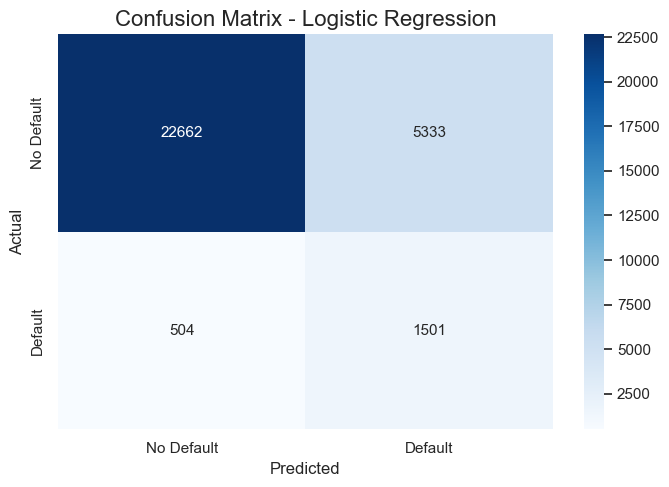

In [30]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

Decision Tree
Accuracy: 0.7837
Precision: 0.2052
Recall: 0.7781
F1 Score: 0.3247
ROC-AUC: 0.852
MAE: 0.2163
RMSE: 0.4651

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     27995
           1       0.21      0.78      0.32      2005

    accuracy                           0.78     30000
   macro avg       0.59      0.78      0.60     30000
weighted avg       0.93      0.78      0.83     30000



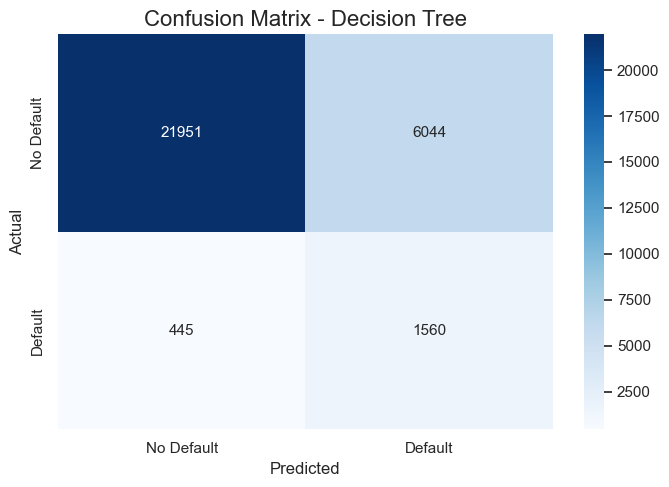

In [31]:
tree_results = evaluate_model(
    decision_tree_model,
    X_test,
    y_test,
    "Decision Tree"
)

In [32]:
results_df = pd.DataFrame([logistic_results, tree_results])

results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,MAE,RMSE
0,Logistic Regression,0.805433,0.219637,0.748628,0.339631,0.861395,0.194567,0.441097
1,Decision Tree,0.783700,0.205155,0.778055,0.324696,0.851993,0.216300,0.465081


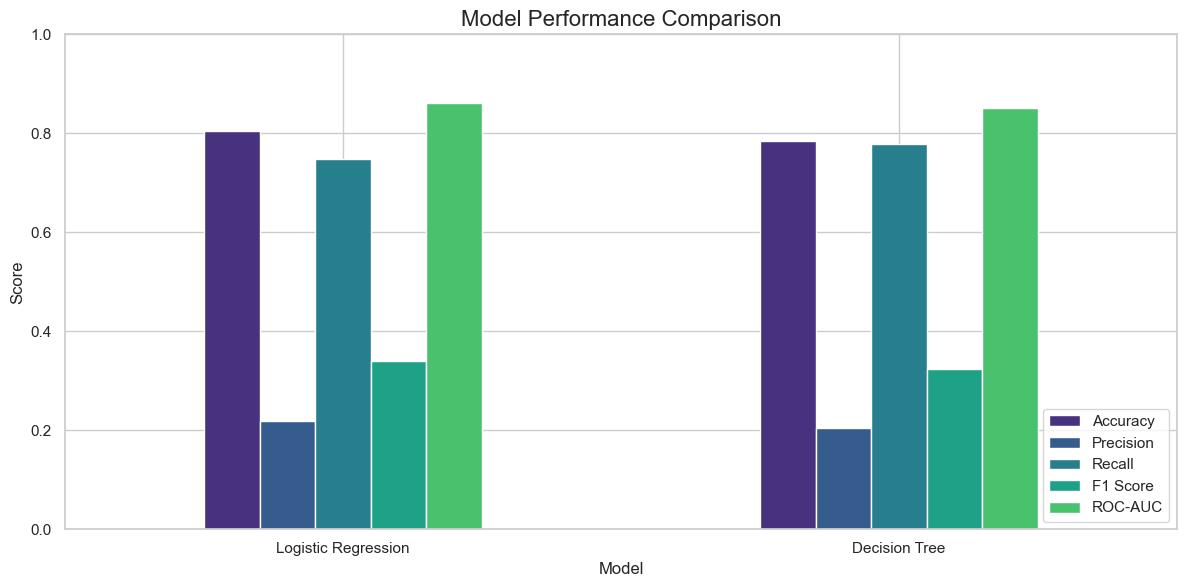

In [33]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

comparison_df = results_df.set_index("Model")[metrics_to_plot]

comparison_df.plot(kind="bar", figsize=(12, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "model_performance_comparison.png", dpi=300)
plt.show()

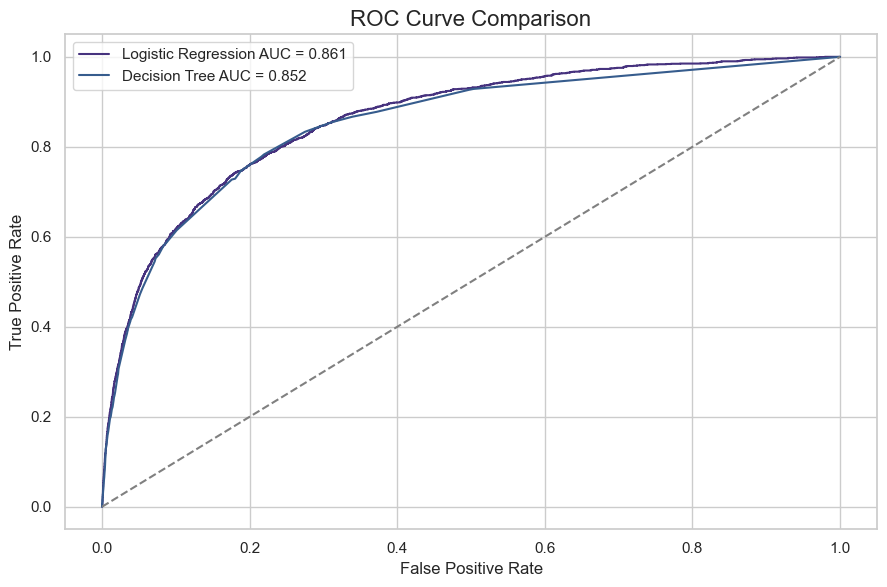

In [34]:
plt.figure(figsize=(9, 6))

# Logistic Regression ROC
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, logistic_prob)

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression AUC = {roc_auc_score(y_test, logistic_prob):.3f}"
)

# Decision Tree ROC
tree_prob = decision_tree_model.predict_proba(X_test)[:, 1]
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_prob)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree AUC = {roc_auc_score(y_test, tree_prob):.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / "roc_curve_comparison.png", dpi=300)
plt.show()

In [35]:
tree_classifier = decision_tree_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.580299
2,NumberOfTime30-59DaysPastDueNotWorse,0.180276
6,NumberOfTimes90DaysLate,0.156865
8,NumberOfTime60-89DaysPastDueNotWorse,0.057434
7,NumberRealEstateLoansOrLines,0.012663
1,age,0.008692
3,DebtRatio,0.002663
4,MonthlyIncome,0.000943
5,NumberOfOpenCreditLinesAndLoans,0.000147
9,NumberOfDependents,0.000016


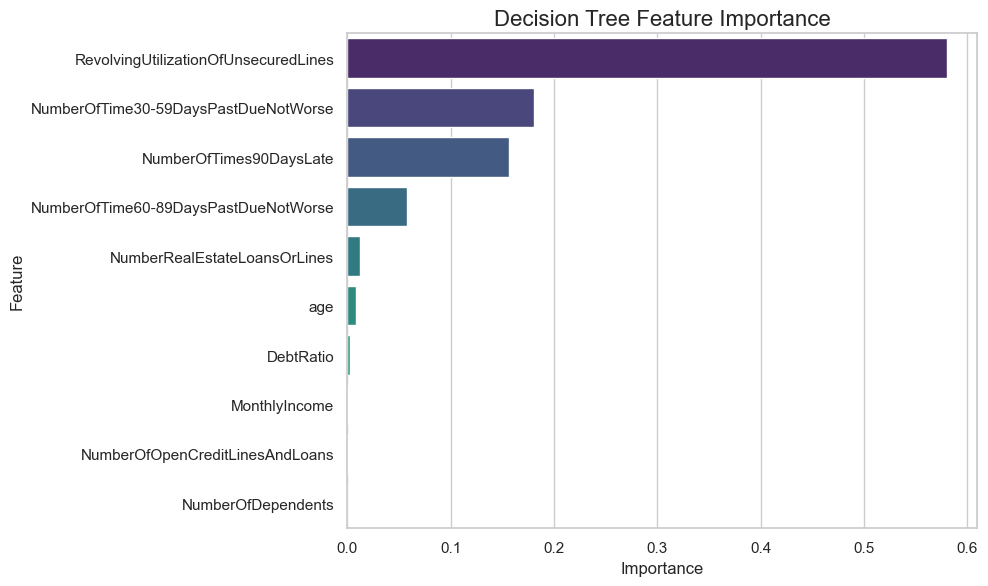

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "decision_tree_feature_importance.png", dpi=300)
plt.show()

In [37]:
best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    best_model = logistic_model
else:
    best_model = decision_tree_model

print("Best Model Selected:", best_model_name)

Best Model Selected: Logistic Regression


In [38]:
model_package = {
    "model": best_model,
    "model_name": best_model_name,
    "features": X.columns.tolist()
}

model_path = MODEL_DIR / "credit_risk_model.pkl"

joblib.dump(model_package, model_path)

print("Model saved successfully at:")
print(model_path)

Model saved successfully at:
D:\Credit Risk Prediction\models\credit_risk_model.pkl


In [39]:
sample_applicant = pd.DataFrame([{
    "RevolvingUtilizationOfUnsecuredLines": 0.45,
    "age": 35,
    "NumberOfTime30-59DaysPastDueNotWorse": 1,
    "DebtRatio": 0.35,
    "MonthlyIncome": 5000,
    "NumberOfOpenCreditLinesAndLoans": 8,
    "NumberOfTimes90DaysLate": 0,
    "NumberRealEstateLoansOrLines": 1,
    "NumberOfTime60-89DaysPastDueNotWorse": 0,
    "NumberOfDependents": 2
}])

prediction = best_model.predict(sample_applicant)[0]
risk_probability = best_model.predict_proba(sample_applicant)[0][1]

print("Prediction:", "Default Risk" if prediction == 1 else "No Default Risk")
print("Default Probability:", round(risk_probability * 100, 2), "%")

Prediction: Default Risk
Default Probability: 55.85 %


In [40]:
report_path = REPORT_DIR / "model_results.csv"

results_df.to_csv(report_path, index=False)

print("Report saved successfully at:")
print(report_path)

Report saved successfully at:
D:\Credit Risk Prediction\outputs\reports\model_results.csv


## Conclusion

In this project, a credit risk prediction model was built using the Give Me Some Credit dataset.

### Work Completed
1. Loaded and explored the dataset.
2. Removed unnecessary columns.
3. Checked and handled missing values.
4. Applied outlier capping to reduce the effect of extreme values.
5. Created multiple EDA visualizations.
6. Trained two machine learning models:
   - Logistic Regression
   - Decision Tree Classifier
7. Evaluated both models using:
   - Accuracy
   - Precision
   - Recall
   - F1 Score
   - ROC-AUC
   - Confusion Matrix
   - MAE
   - RMSE
8. Selected the best model based on ROC-AUC score.
9. Saved the final model for dashboard deployment.

### Key Insights
- Past due payment history is one of the strongest indicators of default risk.
- Monthly income and debt ratio are also useful for understanding credit behavior.
- The dataset is imbalanced, so accuracy alone is not enough.
- ROC-AUC, recall and F1-score give a better understanding of model performance.

### Final Output
The best model has been saved as:

`models/credit_risk_model.pkl`

This model can now be used in a Streamlit dashboard 